In [ ]:
#Importing libraries & loading data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

In [ ]:
churn_df = pd.read_csv('/content/vw_churn_data.csv')
churn_df.head()

,customer_id,gender,age,married,state,number_of_referrals,tenure_in_months,value_deal,multiple_lines,internet_type,...,unlimited_data,contract,paperless_billing,payment_method,monthly_charge,total_charges,total_revenue,customer_status,churn_category,churn_reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,No,Cable,...,Yes,One Year,Yes,Credit Card,65.6,593.30,974.81,Stayed,Others,Others
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Cable,...,No,Month-to-Month,No,Credit Card,-4.0,542.40,610.28,Stayed,Others,Others
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,No,Fiber Optic,...,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,No,Fiber Optic,...,Yes,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,No,Fiber Optic,...,Yes,Month-to-Month,Yes,Credit Card,83.9,267.40,289.54,Churned,Dissatisfaction,Network reliability


In [ ]:
#Data Processing
churn_df= churn_df.drop(['customer_id','churn_category','churn_reason'],axis=1)
#Dropping these 3 columns to prevent data leakage

In [ ]:
#List of columns to be label encoded
columns_to_encode = [
    'gender','married','state','value_deal',
    'multiple_lines','internet_type','online_security',
    'online_backup','device_protection_plan','premium_support','streaming_tv','streaming_movies',
    'streaming_music','unlimited_data','contract','paperless_billing','payment_method']

#Encoding categorical variables except the target variable

label_encoders = {}

for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    churn_df[column] = label_encoders[column].fit_transform(churn_df[column])

#Encoding target variable

churn_df['customer_status']= churn_df['customer_status'].map({'Stayed':0,'Churned':1})

In [ ]:
#Splitting data into features & targets
X = churn_df.drop('customer_status',axis=1)
y = churn_df['customer_status']

#Splitting into training & testing data

X_train,X_test,y_train,y_test = train_test_split( X,y,test_size=0.2,random_state=42)

In [ ]:
#Initializing random forest model

rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

#Training the model

RandomForestClassifier(random_state=42)

In [ ]:
#Model Evaluation

y_pred = rf_model.predict(X_test)

cm = confusion_matrix(y_test,y_pred)
print(cm)

cr = classification_report(y_test,y_pred)
print(cr)

[[791  55]
 [119 237]]
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       846
           1       0.81      0.67      0.73       356

    accuracy                           0.86      1202
   macro avg       0.84      0.80      0.82      1202
weighted avg       0.85      0.86      0.85      1202



In [ ]:
#Feature selection using feature importances

importances = rf_model.feature_importances_
feature_importances =pd.DataFrame({'feature':X.columns,'importance':importances})
feature_importances = feature_importances.sort_values(by='importance',ascending=False)
print(feature_importances.head(10))

                feature  importance
22        total_revenue    0.158908
21        total_charges    0.143864
17             contract    0.129927
20       monthly_charge    0.104481
1                   age    0.075662
5      tenure_in_months    0.055760
3                 state    0.048578
4   number_of_referrals    0.045640
8         internet_type    0.035208
6            value_deal    0.030147


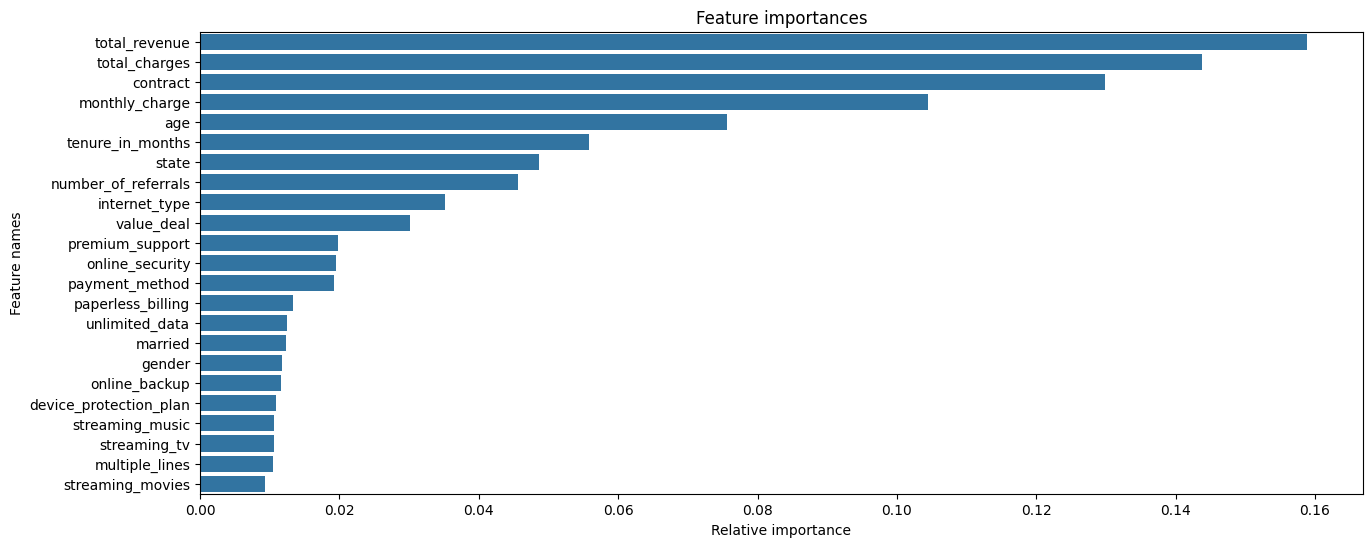

In [ ]:
#Plot the feature importances

plt.figure(figsize = (15,6))
sns.barplot(x=feature_importances['importance'],y=feature_importances['feature'])
plt.title('Feature importances')
plt.xlabel('Relative importance')
plt.ylabel('Feature names')
plt.show()

In [ ]:
#Predicting on New Data ( Customers who Joined the business)

new_data = pd.read_csv('/content/vw_joined_data.csv')
new_data.head()

,customer_id,gender,age,married,state,number_of_referrals,tenure_in_months,value_deal,multiple_lines,internet_type,...,unlimited_data,contract,paperless_billing,payment_method,monthly_charge,total_charges,total_revenue,customer_status,churn_category,churn_reason
0,93520-GUJ,Female,67,No,Gujarat,13,19,Deal 5,Yes,Fiber Optic,...,Yes,One Year,Yes,Bank Withdrawal,72.10,72.1,79.87,Joined,Others,Others
1,57256-BIH,Female,18,No,Bihar,9,7,NaN,No,NaN,...,No,Month-to-Month,No,Credit Card,19.85,57.2,66.56,Joined,Others,Others
2,72357-MAD,Female,53,No,Madhya Pradesh,14,12,Deal 5,No,DSL,...,Yes,Month-to-Month,Yes,Credit Card,44.30,44.3,87.25,Joined,Others,Others
3,66612-KAR,Female,58,Yes,Karnataka,11,18,NaN,No,NaN,...,No,Month-to-Month,No,Credit Card,19.95,58.0,66.07,Joined,Others,Others
4,22119-WES,Male,31,Yes,West Bengal,5,5,NaN,No,NaN,...,No,Month-to-Month,No,Credit Card,20.05,33.7,37.32,Joined,Others,Others


In [ ]:
#Creating a backup copy because later Labelencoder will convert text into values
Original_data=new_data.copy()

#Retaining Customer_id column
cuteomer_ids= new_data['customer_id']

In [ ]:
#Dropping columns that won't be used for prediction
new_data =new_data.drop(['customer_id',
     'customer_status',
     'churn_category',
     'churn_reason'],
    axis=1
)



In [ ]:
print(new_data.columns.tolist())

['gender', 'age', 'married', 'state', 'number_of_referrals', 'tenure_in_months', 'value_deal', 'multiple_lines', 'internet_type', 'online_security', 'online_backup', 'device_protection_plan', 'premium_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'unlimited_data', 'contract', 'paperless_billing', 'payment_method', 'monthly_charge', 'total_charges', 'total_revenue']


In [ ]:
#Encoding categorical variables using the saved label encoders
for column in new_data.select_dtypes(include=['object']).columns:
    new_data[column] = label_encoders[column].transform(new_data[column])

In [ ]:
new_data.head()

,gender,age,married,state,number_of_referrals,tenure_in_months,value_deal,multiple_lines,internet_type,online_security,...,streaming_tv,streaming_movies,streaming_music,unlimited_data,contract,paperless_billing,payment_method,monthly_charge,total_charges,total_revenue
0,0,67,0,5,13,19,4,1,2,0,...,0,0,0,1,1,1,0,72.10,72.1,79.87
1,0,18,0,2,9,7,5,0,3,0,...,0,0,0,0,0,0,1,19.85,57.2,66.56
2,0,53,0,11,14,12,4,0,1,0,...,0,0,0,1,0,1,1,44.30,44.3,87.25
3,0,58,1,9,11,18,5,0,3,0,...,0,0,0,0,0,0,1,19.95,58.0,66.07
4,1,31,1,21,5,5,5,0,3,0,...,0,0,0,0,0,0,1,20.05,33.7,37.32


In [ ]:
#Making predictions
new_predictions = rf_model.predict(new_data)
print (new_predictions[:10])

[1 1 1 1 1 1 1 1 1 1]


In [ ]:
#Adding predictions back to the original_data
Original_data['Customer_Status_Predited']=new_predictions

In [ ]:
#Filtering the dataframe to include only records predicted as Churned
churn_risk_customers =Original_data[Original_data['Customer_Status_Predited'] ==1]

In [ ]:
print(churn_risk_customers.shape)
churn_risk_customers.head()

(377, 28)


,customer_id,gender,age,married,state,number_of_referrals,tenure_in_months,value_deal,multiple_lines,internet_type,...,contract,paperless_billing,payment_method,monthly_charge,total_charges,total_revenue,customer_status,churn_category,churn_reason,Customer_Status_Predited
0,93520-GUJ,Female,67,No,Gujarat,13,19,Deal 5,Yes,Fiber Optic,...,One Year,Yes,Bank Withdrawal,72.10,72.1,79.87,Joined,Others,Others,1
1,57256-BIH,Female,18,No,Bihar,9,7,NaN,No,NaN,...,Month-to-Month,No,Credit Card,19.85,57.2,66.56,Joined,Others,Others,1
2,72357-MAD,Female,53,No,Madhya Pradesh,14,12,Deal 5,No,DSL,...,Month-to-Month,Yes,Credit Card,44.30,44.3,87.25,Joined,Others,Others,1
3,66612-KAR,Female,58,Yes,Karnataka,11,18,NaN,No,NaN,...,Month-to-Month,No,Credit Card,19.95,58.0,66.07,Joined,Others,Others,1
4,22119-WES,Male,31,Yes,West Bengal,5,5,NaN,No,NaN,...,Month-to-Month,No,Credit Card,20.05,33.7,37.32,Joined,Others,Others,1


In [ ]:
#Checking the count of the newdata set
pd.Series(new_predictions).value_counts()
#Total customers evaluated = 411,Predicted churn = 377,stay = 34

,count
1,377
0,34


In [ ]:
#Save the results
Original_data.to_csv('all_customers_predictions.csv', index = False)